# 01 — Exploratory Data Analysis
**Spotify Dataset 1921–2020** · ~600k tracks · Source: [Kaggle](https://www.kaggle.com/datasets/yamaerenay/spotify-dataset-19212020-600k-tracks)

### Purpose
First look at the clean dataset. This notebook answers:
- What does the dataset contain, and how is it structured?
- How are each audio feature distributed?
- Did the cleaning pipeline change the distributions in the expected way?

### Sections
| # | Section |
|---|---------|
| 1 | Load & dataset overview |
| 2 | Feature distributions (raw) |
| 3 | Before / after cleaning comparison |
| 4 | Findings |


## 0 · Imports & Configuration

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from shared.config import PATHS, PALETTE, FEATURES, set_style
from shared.plot_utils import make_fig

set_style()

---
## 1 · Load & Dataset Overview

In [2]:
# [STEP 1] - Load clean parquet (all dtypes preserved)
tracks_clean = pd.read_parquet(PATHS['clean'])

print(f"Shape : {tracks_clean.shape}")
print(f"Memory: {tracks_clean.memory_usage(deep=True).sum() / 1e6:.1f} MB")
tracks_clean.head()

Shape : (569604, 28)
Memory: 298.9 MB


,id,name,popularity,duration_min,explicit,artists,id_artists,release_date,danceability,energy,...,tempo,time_signature,main_artist,id_main_artist,key_name,mode_name,year,decade,speechiness_sqrt,instrumentalness_sqrt
0,35iwgR4jXetI318WEWsa1Q,Carve,6,2.115050,0,[Uli],[45tIt06XoI0Iio4LBEVpls],1922-02-22,0.645,0.445,...,104.851,3,Uli,45tIt06XoI0Iio4LBEVpls,C,Major,1922,1920,0.671565,0.862554
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,1.636667,0,[Fernando Pessoa],[14jtPCOoNZwquk5wd9DxrY],1922-06-01,0.695,0.263,...,102.009,1,Fernando Pessoa,14jtPCOoNZwquk5wd9DxrY,C,Major,1922,1920,0.978264,0.000000
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,3.027333,0,[Ignacio Corsini],[5LiOoJbxVSAMkBS2fUm3X2],1922-03-21,0.434,0.177,...,130.418,5,Ignacio Corsini,5LiOoJbxVSAMkBS2fUm3X2,C♯,Major,1922,1920,0.226274,0.147648
3,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,2.718000,0,[Dick Haymes],[3BiJGZsyX9sJchTqcSA7Su],1922-01-01,0.402,0.158,...,103.220,4,Dick Haymes,3BiJGZsyX9sJchTqcSA7Su,D♯,Minor,1922,1920,0.197484,0.360555
4,0BRXJHRNGQ3W4v9frnSfhu,Ave Maria,0,2.982217,0,[Dick Haymes],[3BiJGZsyX9sJchTqcSA7Su],1922-01-01,0.227,0.261,...,118.891,4,Dick Haymes,3BiJGZsyX9sJchTqcSA7Su,F,Major,1922,1920,0.195448,0.496991


In [ ]:
# [STEP 2] - Column overview: dtypes and null counts

# Drop ndarray columns; equivalent information is already captured
# by 'main_artist' and 'id_main_artist'
exclude_cols = ['artists', 'id_artists']

info = pd.DataFrame({
    'dtype'  : tracks_clean.drop(columns=exclude_cols).dtypes,
    'nulls'  : tracks_clean.drop(columns=exclude_cols).isnull().sum(),
    'null_%' : (tracks_clean.drop(columns=exclude_cols).isnull().mean() * 100).round(2),
    'unique' : tracks_clean.drop(columns=exclude_cols).nunique()
})

info

,dtype,nulls,null_%,unique
id,str,0,0.0,569604
name,str,0,0.0,433276
popularity,int64,0,0.0,101
duration_min,float64,0,0.0,118412
explicit,int64,0,0.0,2
release_date,datetime64[us],0,0.0,19236
danceability,float64,0,0.0,1252
energy,float64,0,0.0,2071
key,int64,0,0.0,12
loudness,float64,0,0.0,26092


In [4]:
# [STEP 3] - Descriptive statistics for all audio features
tracks_clean[FEATURES['all']].describe().round(3)

,acousticness,danceability,energy,instrumentalness,liveness,speechiness,valence,loudness,tempo,duration_min
count,569604.000,569604.000,569604.000,569604.000,569604.000,569604.000,569604.000,569604.000,569604.000,569604.000
mean,0.444,0.568,0.547,0.108,0.212,0.105,0.556,-10.024,117.950,3.741
std,0.347,0.163,0.249,0.260,0.181,0.180,0.255,4.736,28.561,1.419
min,0.000,0.053,0.000,0.000,0.006,0.022,0.000,-27.945,34.566,0.501
25%,0.093,0.459,0.351,0.000,0.098,0.034,0.351,-12.749,95.727,2.921
50%,0.412,0.581,0.553,0.000,0.139,0.044,0.567,-9.181,117.181,3.578
75%,0.776,0.689,0.750,0.008,0.276,0.076,0.771,-6.456,135.977,4.379
max,0.996,0.991,1.000,1.000,1.000,0.971,0.999,5.376,197.401,13.117


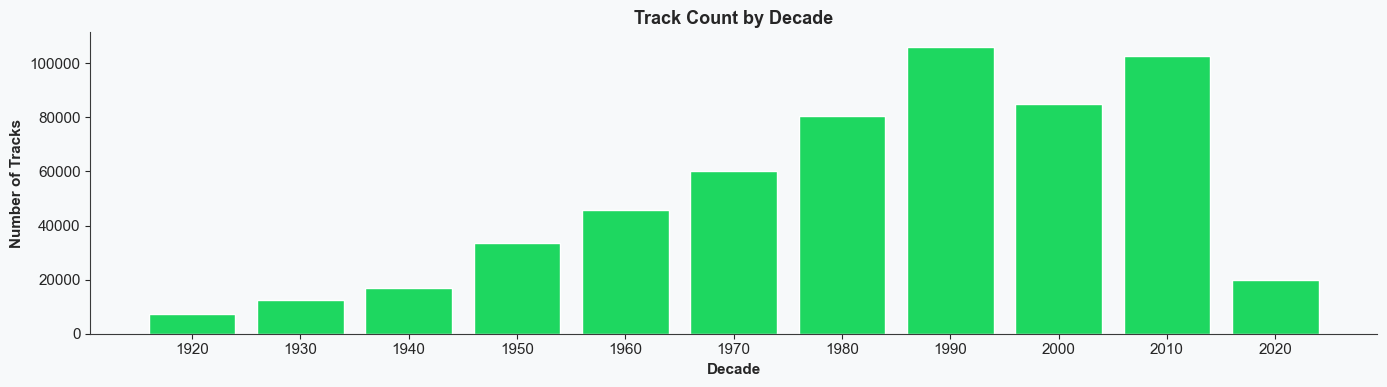

In [8]:
# [STEP 4] - Track count by decade (dataset coverage)
decade_counts = tracks_clean.groupby('decade')['id'].count()

fig, ax = make_fig(figsize=(14, 4))

ax.bar(decade_counts.index, decade_counts.values,
       width=8, color=PALETTE['green'], edgecolor='white')

ax.set_title('Track Count by Decade', fontsize=13)
ax.set_xlabel('Decade')
ax.set_ylabel('Number of Tracks')
ax.set_xticks(decade_counts.index)

plt.tight_layout()
plt.show()

> **Note:** The dataset is heavily skewed toward recent decades —  
> the streaming era (2000–2020) contains the vast majority of tracks.  
> This imbalance is accounted for in the clustering phase via stratified sampling.

---
## 2 · Feature Distributions

### 2.1 All audio features — overview grid

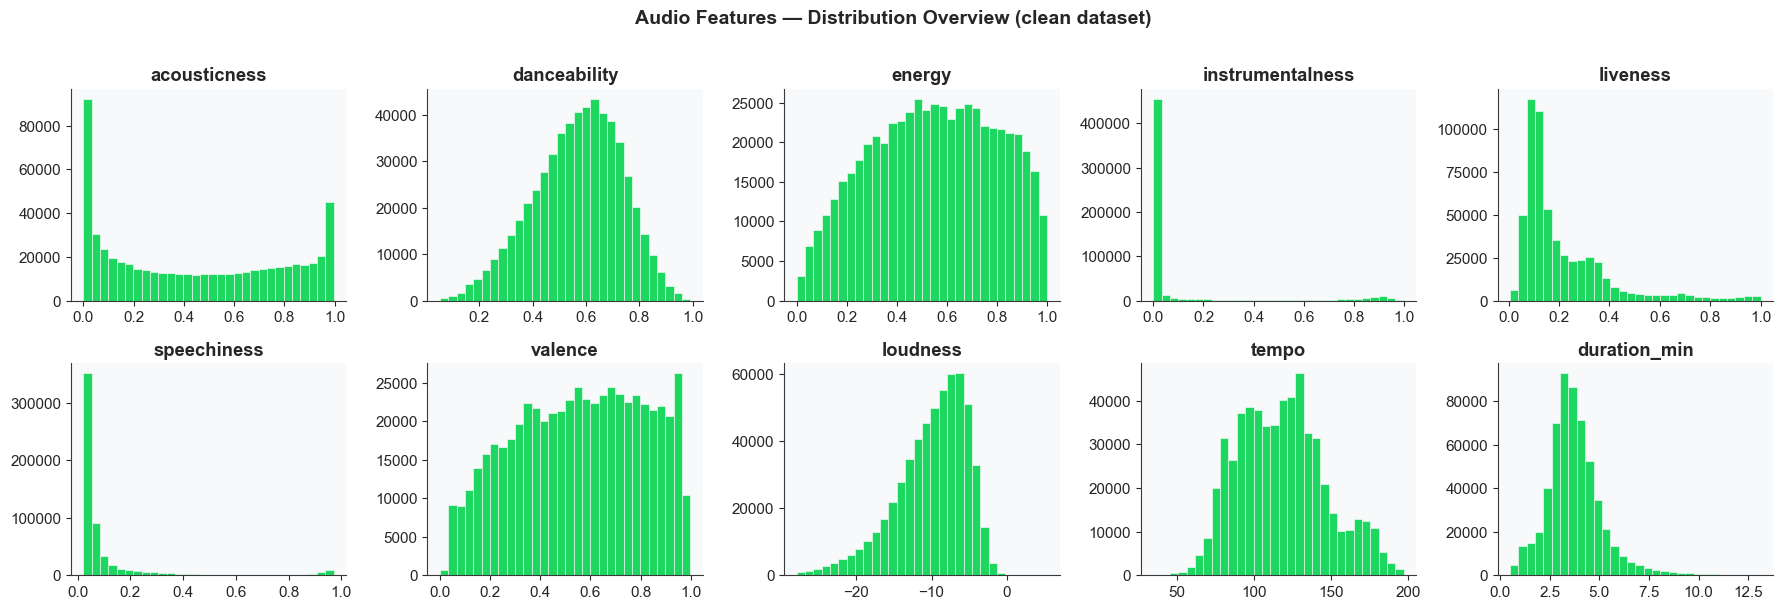

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
axes = axes.flatten()

for i, feature in enumerate(FEATURES['all']):
    axes[i].hist(tracks_clean[feature].dropna(), bins=30,
                 color=PALETTE['green'], edgecolor='white', linewidth=0.4,)
    axes[i].set_title(feature, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    sns.despine(ax=axes[i])

# Hide unused axes (grid has 10 slots, features list may vary)
for j in range(len(FEATURES['all']), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Audio Features — Distribution Overview (clean dataset)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.2 Bounded features (0–1) — detail

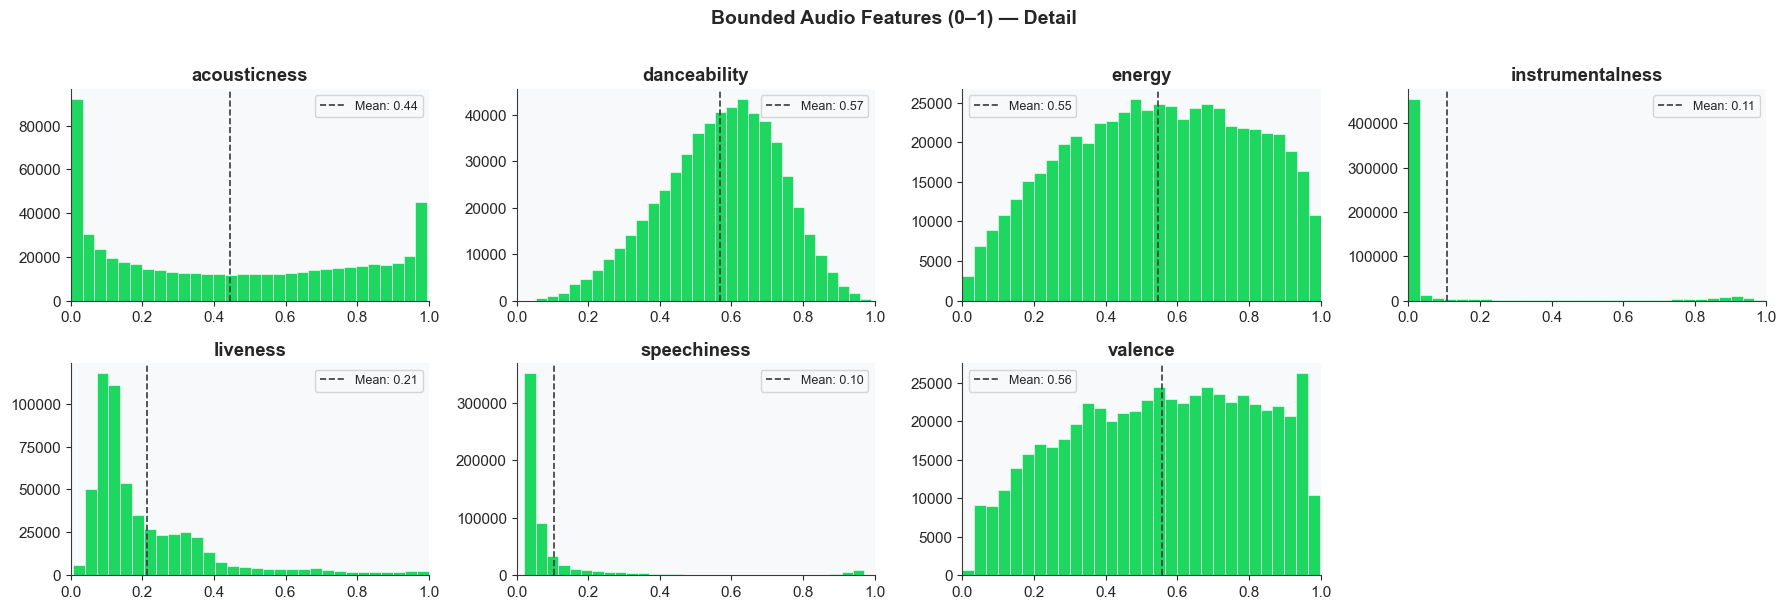

In [12]:
# Bounded features share the same x-axis range → easier visual comparison
fig, axes = plt.subplots(2, 4, figsize=(18, 6), sharey=False)
axes = axes.flatten()

for i, feature in enumerate(FEATURES['bounded']):
    axes[i].hist(tracks_clean[feature].dropna(), bins=30,
                 color=PALETTE['green'], edgecolor='white', linewidth=0.4)

    mean_val = tracks_clean[feature].mean()
    axes[i].axvline(mean_val, color=PALETTE['dark'], linestyle='--',
                    linewidth=1.2, label=f'Mean: {mean_val:.2f}')

    axes[i].set_title(feature, fontweight='bold')
    axes[i].set_xlim(0, 1)
    axes[i].legend(fontsize=9)
    sns.despine(ax=axes[i])

for j in range(len(FEATURES['bounded']), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Bounded Audio Features (0–1) — Detail',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.3 Categorical features — key, mode, time signature

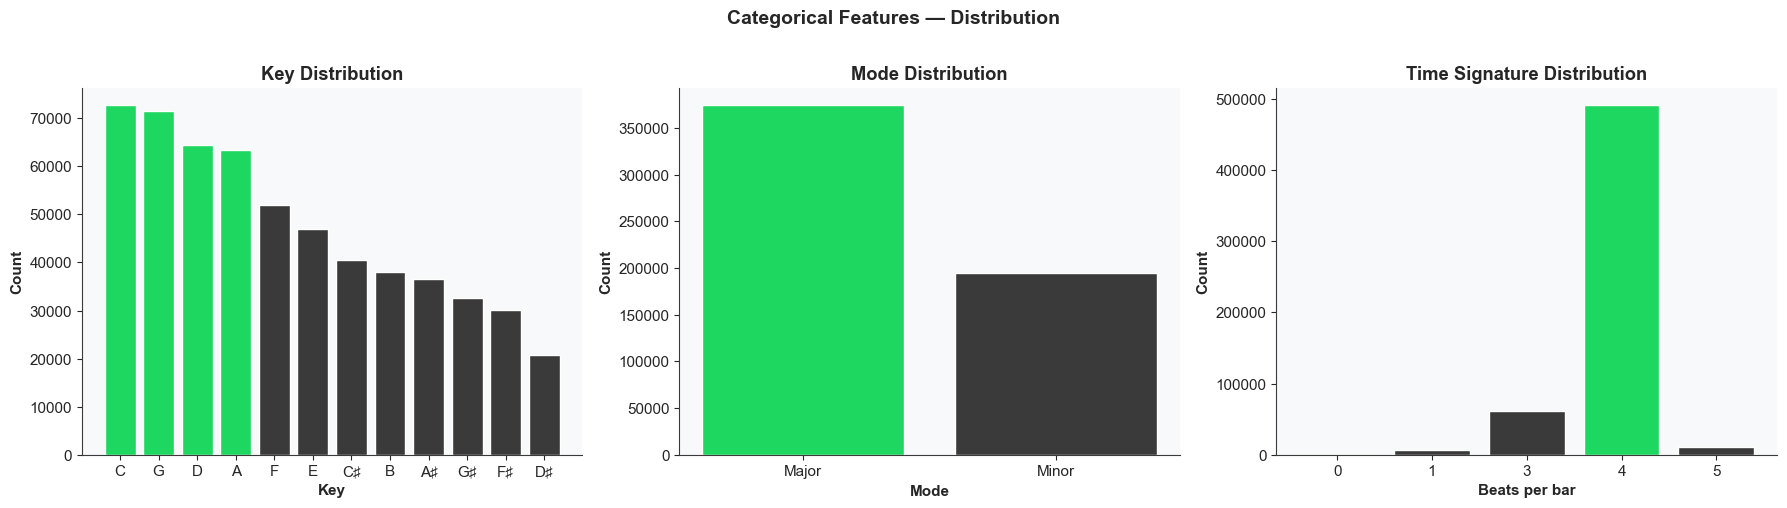

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -- Key distribution --
key_counts = tracks_clean['key_name'].value_counts()
axes[0].bar(key_counts.index, key_counts.values,
            color=[PALETTE['green'], PALETTE['green'], PALETTE['green'], PALETTE['green'], 
                   PALETTE['dark'], PALETTE['dark'], PALETTE['dark'], PALETTE['dark'], 
                   PALETTE['dark'], PALETTE['dark'], PALETTE['dark'], PALETTE['dark']], 
            edgecolor='white')
axes[0].set_title('Key Distribution', fontweight='bold')
axes[0].set_xlabel('Key')
axes[0].set_ylabel('Count')
sns.despine(ax=axes[0])

# -- Mode distribution --
mode_counts = tracks_clean['mode_name'].value_counts()
axes[1].bar(mode_counts.index, mode_counts.values,
            color=[PALETTE['green'], PALETTE['dark']],
            edgecolor='white')
axes[1].set_title('Mode Distribution', fontweight='bold')
axes[1].set_xlabel('Mode')
axes[1].set_ylabel('Count')
sns.despine(ax=axes[1])

# -- Time signature distribution --
ts_counts = tracks_clean['time_signature'].value_counts().sort_index()
axes[2].bar(ts_counts.index.astype(str), ts_counts.values,
            color=[PALETTE['dark'], PALETTE['dark'], PALETTE['dark'], PALETTE['green'], PALETTE['dark']], 
            edgecolor='white')
axes[2].set_title('Time Signature Distribution', fontweight='bold')
axes[2].set_xlabel('Beats per bar')
axes[2].set_ylabel('Count')
sns.despine(ax=axes[2])

plt.suptitle('Categorical Features — Distribution',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 3 · Before / After Cleaning

Comparison of distributions for the three features that were actively cleaned  
(`tempo`, `loudness`, `duration_min`). The mean line shows how the central  
tendency shifted after outlier removal.

In [22]:
# [STEP 1] - Reload raw data for comparison
tracks_raw = pd.read_csv(PATHS['raw'])
tracks_raw['duration_min'] = tracks_raw['duration_ms'] / (1000 * 60)

# Shift loudness to positive for visual consistency
LOUDNESS_SHIFT = abs(tracks_raw['loudness'].min())

cleaned_cols = ['tempo', 'loudness', 'duration_min']

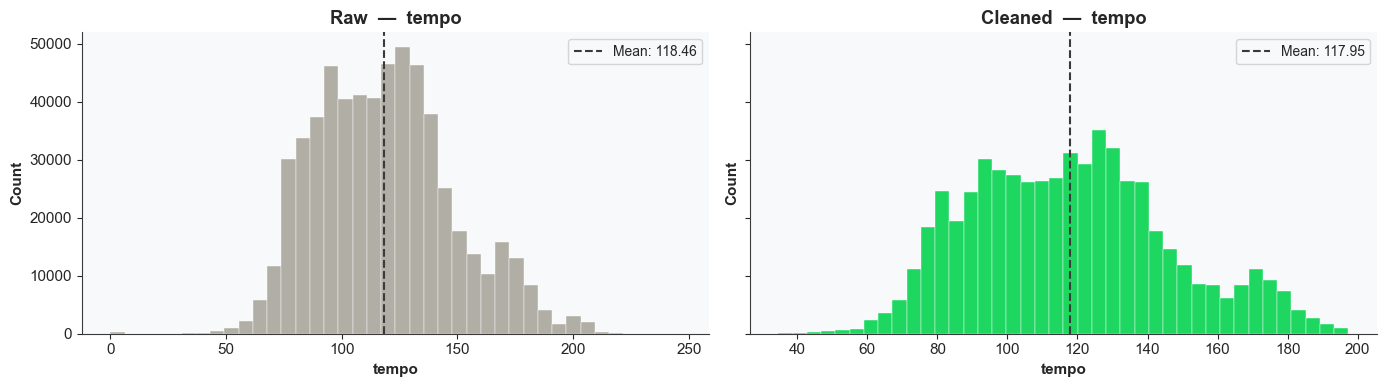

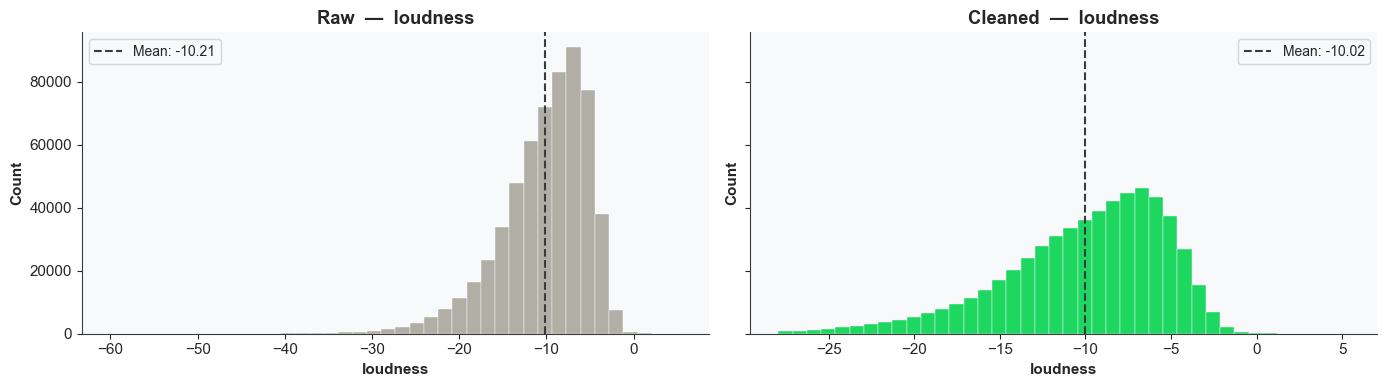

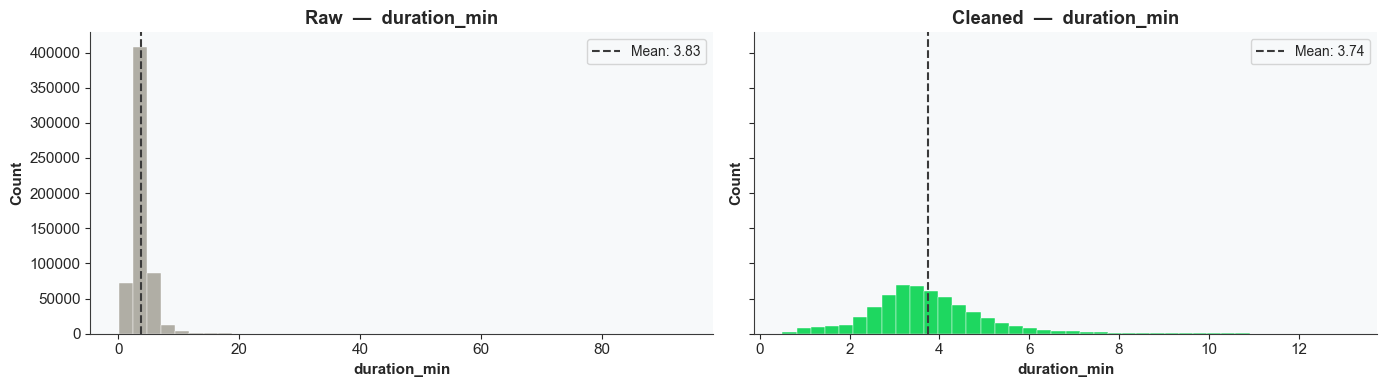

In [23]:
# [STEP 2] - Side-by-side histograms: raw vs clean
for col in cleaned_cols:

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

    for ax, df, label, color in zip(
        axes,
        [tracks_raw, tracks_clean],
        ['Raw', 'Cleaned'],
        [PALETTE['stone'], PALETTE['green']]
    ):
        ax.hist(df[col].dropna(), bins=40, color=color,
                edgecolor='white', linewidth=0.3)
        mean_val = df[col].mean()
        ax.axvline(mean_val, color=PALETTE['dark'], linestyle='--',
                   linewidth=1.5, label=f'Mean: {mean_val:.2f}')
        ax.set_title(f'{label}  —  {col}', fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('Count')
        ax.legend(fontsize=10)
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

---
## 4 · Findings

#### Dataset structure
- The dataset spans 1921–2020 but is heavily concentrated in the 2000–2020 decade,  
  which accounts for the majority of tracks. Older eras are progressively underrepresented.
- No critical null values remain in audio feature columns after cleaning.

#### Bounded features (0–1)
- **Acousticness** and **instrumentalness** are strongly right-skewed:  
  most tracks score low, with a long tail of highly acoustic or instrumental content.
- **Speechiness** is similarly skewed — the vast majority of tracks are music,  
  not spoken word (values below 0.33).
- **Danceability**, **energy**, and **valence** are roughly bell-shaped,  
  centered around 0.5–0.65.
- **Liveness** is right-skewed and stable: most tracks score below 0.3,  
  consistent with studio recordings dominating the dataset.

#### Unbounded features
- **Tempo** is approximately normal after IQR cleaning, centered around 120 BPM.
- **Loudness** distribution is left-skewed (most tracks cluster between −8 and −4 dB),  
  consistent with the loudness war observed in the temporal analysis.
- **Duration** is right-skewed even after Log+IQR cleaning — a long tail of  
  extended tracks (live recordings, classical pieces) remains at the conservative fence=3.

#### Categorical features
- **Key**: natural keys (C, G, D) dominate; sharps/flats are underrepresented.
- **Mode**: ~60% Major, ~40% Minor across the full dataset.
- **Time signature**: overwhelmingly 4/4, as expected for popular music.

> **→ Next notebook:** `02_temporal_analysis.ipynb` — how audio features evolved from 1921 to 2020.